# 편미분계수, 미분과 선형대수의 관계, Gradient, Curl, Divergence (뉴진수 7강)-10강 3기 07강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y = sp.symbols("x y", real=True)
dx, dy = sp.symbols("Delta_x Delta_y", real=True)

## 1. $\langle\nabla f(P),K\rangle$ 가 높이 변화가 되는 이유
표준 내적으로 $\nabla f=(f_x,f_y)$, 변위 $K=(\Delta x,\Delta y)$ 이면
$\langle\nabla f(P),K\rangle=f_x\,\Delta x+f_y\,\Delta y$ 가 1차 높이 변화입니다.
선형함수 $f(x,y)=2x+3y$ 에서는 근사가 아니라 **정확히** 성립합니다.

In [2]:
f_lin = 2 * x + 3 * y
grad = sp.Matrix([sp.diff(f_lin, x), sp.diff(f_lin, y)])
K = sp.Matrix([dx, dy])
print("grad f      =", grad.T.tolist()[0])
print("<grad f, K> =", (grad.T * K)[0])

# exact increment for the linear function f = 2x+3y
P = sp.Matrix([x, y])
increment = f_lin.subs({x: x + dx, y: y + dy}) - f_lin
print("f(P+K)-f(P) =", sp.expand(increment), "  (matches the inner product exactly)")

# a non-linear check: first-order term of f = x**2 + x*y at P=(1,1)
g = x**2 + x * y
gP = sp.Matrix([sp.diff(g, x), sp.diff(g, y)]).subs({x: 1, y: 1})
print("non-linear g=x^2+xy at P=(1,1):  grad =", gP.T.tolist()[0],
      "  linear part = ", (gP.T * K)[0])

grad f      = [2, 3]
<grad f, K> = 2*Delta_x + 3*Delta_y
f(P+K)-f(P) = 2*Delta_x + 3*Delta_y   (matches the inner product exactly)
non-linear g=x^2+xy at P=(1,1):  grad = [3, 1]   linear part =  3*Delta_x + Delta_y


## 2. 음함수 조건과 수직 기울기
레벨셋 $F(x,y)=0$ 위에서 움직이면 $F$ 값이 변하지 않으므로 접방향 $d$ 에 대해
$\langle\nabla F,d\rangle=0$. 원 $F=x^2+y^2-1$ 로 확인합니다.

In [3]:
F = x**2 + y**2 - 1
gradF = sp.Matrix([sp.diff(F, x), sp.diff(F, y)])
print("grad F =", gradF.T.tolist()[0])
for (px, py), tangent in [((1, 0), (0, 1)), ((0, 1), (1, 0))]:
    gP = gradF.subs({x: px, y: py})
    d = sp.Matrix(tangent)
    print(f"  P=({px},{py}):  grad F={gP.T.tolist()[0]}   tangent={tangent}   <grad F, d>={(gP.T*d)[0]}")

grad F = [2*x, 2*y]
  P=(1,0):  grad F=[2, 0]   tangent=(0, 1)   <grad F, d>=0
  P=(0,1):  grad F=[0, 2]   tangent=(1, 0)   <grad F, d>=0


## 4. 컬: 흐름 속 물체가 자전하는 양
2차원 컬 $\operatorname{curl}F=\partial_x F_2-\partial_y F_1$.
회전장 $F=(-y,\,x)$ 는 원점 둘레로 반시계방향이며 컬이 상수 $2$ 입니다.

In [4]:
def curl2d(F1, F2):
    return sp.diff(F2, x) - sp.diff(F1, y)

F1, F2 = -y, x
print("F = (-y, x):  curl =", curl2d(F1, F2))
# the four sample arrows quoted in the note
for (px, py) in [(1, 0), (0, 1), (-1, 0), (0, -1)]:
    vec = (F1.subs({x: px, y: py}), F2.subs({x: px, y: py}))
    print(f"  at ({px:2},{py:2})  ->  arrow {vec}")

F = (-y, x):  curl = 2
  at ( 1, 0)  ->  arrow (0, 1)
  at ( 0, 1)  ->  arrow (-1, 0)
  at (-1, 0)  ->  arrow (0, -1)
  at ( 0,-1)  ->  arrow (1, 0)


## 7. 발산: 소스와 싱크를 재는 양
2차원 발산 $\operatorname{div}F=\partial_x F_1+\partial_y F_2$.
바깥으로 뻗는 $F=(x,y)$ 는 $\operatorname{div}=2$, 회전장 $F=(-y,x)$ 는 $\operatorname{div}=0$.

In [5]:
def div2d(F1, F2):
    return sp.diff(F1, x) + sp.diff(F2, y)

print("F = (x, y):    div =", div2d(x, y),   "   curl =", curl2d(x, y))
print("F = (-x,-y):   div =", div2d(-x, -y), "   curl =", curl2d(-x, -y))
print("F = (-y, x):   div =", div2d(-y, x),  "   curl =", curl2d(-y, x))

F = (x, y):    div = 2    curl = 0
F = (-x,-y):   div = -2    curl = 0
F = (-y, x):   div = 0    curl = 2


## 10. 예시 벡터장으로 구분하기 — 퍼짐 vs 돎
같은 점들에 화살표를 그려도 $F=(x,y)$ 는 **순수 발산** (div=2, curl=0),
$F=(-y,x)$ 는 **순수 회전** (div=0, curl=2)으로 갈립니다.
작은 원판을 두고 플럭스(바깥으로 나가는 양)와 순환(둘레를 도는 양)을 수치로도 확인합니다.

In [6]:
fields = {
    "F=(x,y)  source": lambda X, Y: (X, Y),
    "F=(-y,x) rotation": lambda X, Y: (-Y, X),
}
for name, fld in fields.items():
    print(f"{name:>20}:  div = {sp.simplify(div2d(*fld(x, y)))}    curl = {sp.simplify(curl2d(*fld(x, y)))}")

# numerical flux / circulation around the unit circle (Green's theorem sanity check)
th = np.linspace(0, 2 * np.pi, 2000, endpoint=False)
cx, cy = np.cos(th), np.sin(th)             # boundary points (unit circle)
nx, ny = np.cos(th), np.sin(th)             # outward normal
tx, ty = -np.sin(th), np.cos(th)            # counter-clockwise tangent
ds = 2 * np.pi / len(th)
for name, fld in fields.items():
    Fx, Fy = fld(cx, cy)
    flux = np.sum((Fx * nx + Fy * ny)) * ds          # ~ integral of div over the disk
    circ = np.sum((Fx * tx + Fy * ty)) * ds          # ~ integral of curl over the disk
    print(f"{name:>20}:  flux ~ {flux:6.3f} (= div*pi)   circulation ~ {circ:6.3f} (= curl*pi)")

     F=(x,y)  source:  div = 2    curl = 0
   F=(-y,x) rotation:  div = 0    curl = 2
     F=(x,y)  source:  flux ~  6.283 (= div*pi)   circulation ~  0.000 (= curl*pi)
   F=(-y,x) rotation:  flux ~  0.000 (= div*pi)   circulation ~  6.283 (= curl*pi)


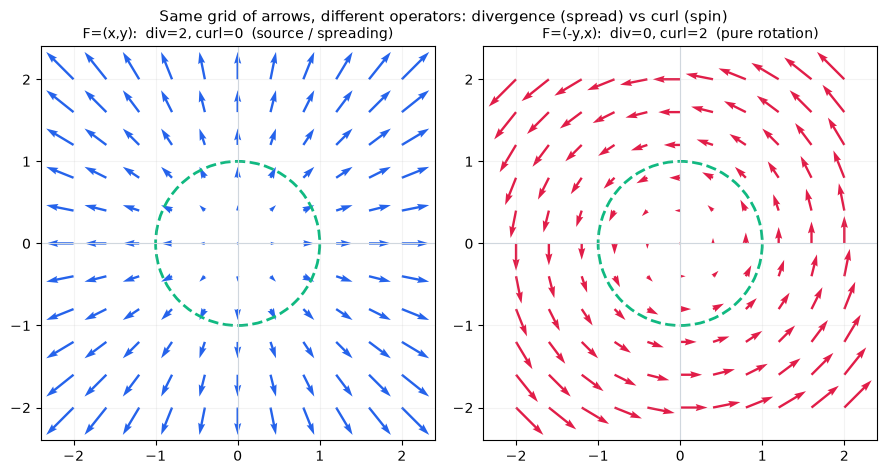

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
gx, gy = np.meshgrid(np.linspace(-2, 2, 11), np.linspace(-2, 2, 11))
panels = [
    ("F=(x,y):  div=2, curl=0  (source / spreading)", gx, gy, "#2563eb"),
    ("F=(-y,x):  div=0, curl=2  (pure rotation)", -gy, gx, "#e11d48"),
]
for ax, (title, U, V, color) in zip(axes, panels):
    ax.quiver(gx, gy, U, V, color=color, angles="xy", scale_units="xy", scale=6, width=0.006)
    disk = plt.Circle((0, 0), 1.0, fill=False, color="#10b981", lw=2, ls="--")
    ax.add_patch(disk)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.4, 2.4); ax.set_aspect("equal")
    ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
    ax.grid(alpha=.15)
fig.suptitle("Same grid of arrows, different operators: divergence (spread) vs curl (spin)", fontsize=11)
fig.tight_layout()
plt.show()